# Several views on cross-entropy — synthetic experiments

Companion notebook to the post. Four small experiments, each isolating one idea:

1. **A coin** — maximum likelihood recovers the coin's bias, and the negative
   log-likelihood *is* binary cross-entropy.
2. **The identity** — checking $H(p,q) = H(p) + D_{\mathrm{KL}}(p\|q)$ numerically.
3. **Calibration** — temperature scaling lowers cross-entropy while accuracy stays
   flat (cross-entropy is a proper scoring rule; accuracy is not).
4. **Forward vs. reverse KL** — fitting one Gaussian to a bimodal target pulls in
   two different directions (mode-covering vs. mode-seeking).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- site theme -----------------------------------------------------------
BG, PANEL, LINE = "#0e1116", "#151a21", "#222a35"
FG, MUTED, ACCENT, ACCENT2 = "#d7dde6", "#8a94a3", "#4aa3ff", "#e0a458"

mpl.rcParams.update({
    "figure.facecolor": PANEL, "axes.facecolor": PANEL, "savefig.facecolor": PANEL,
    "axes.edgecolor": LINE, "axes.labelcolor": FG, "text.color": FG,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": LINE,
    "axes.grid": True, "grid.linewidth": 0.6, "grid.alpha": 0.7,
    "font.family": "monospace", "font.size": 11, "figure.dpi": 120,
    "axes.titlesize": 12, "legend.frameon": False, "legend.labelcolor": FG,
})

def style(ax):
    """Hide top/right spines, color the rest — the house look."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(LINE)
    return ax

rng = np.random.default_rng(0)
eps = 1e-12  # keeps logs finite

## 1. A coin: maximum likelihood = minimizing cross-entropy

Flip a biased coin $n$ times. For a candidate bias $p$, the per-sequence negative
log-likelihood is

$$ \text{NLL}(p) = -\big[k \log p + (n-k)\log(1-p)\big], \qquad k = \#\text{heads}. $$

This is binary cross-entropy with a constant prediction $p$. Its minimum sits exactly
at the empirical frequency $k/n$, and as $n$ grows that estimate converges to the true
bias. Left: the NLL curve. Right: estimates tightening around the truth.

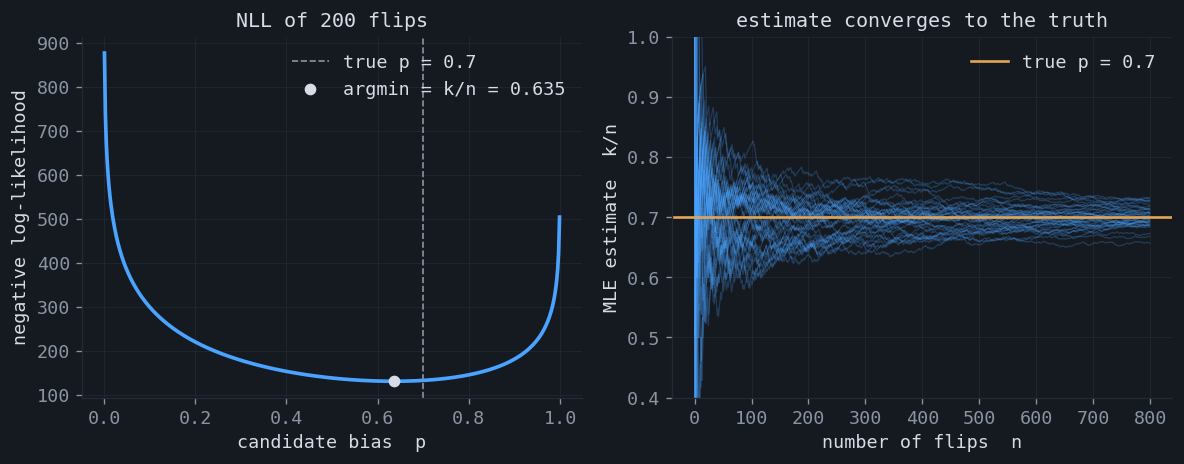

closed-form MLE  k/n = 0.635   (true 0.7)


In [2]:
true_p = 0.7
n = 200
flips = (rng.random(n) < true_p).astype(int)
k = flips.sum()

p_grid = np.linspace(1e-3, 1 - 1e-3, 500)
nll = -(k * np.log(p_grid) + (n - k) * np.log(1 - p_grid))
p_hat = k / n  # the analytic minimizer

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- left: the NLL curve ---
ax1.plot(p_grid, nll, color=ACCENT, lw=2.2)
ax1.axvline(true_p, color=MUTED, ls="--", lw=1, label=f"true p = {true_p}")
ax1.scatter([p_hat], [-(k*np.log(p_hat)+(n-k)*np.log(1-p_hat))],
            color=FG, s=36, zorder=5, label=f"argmin = k/n = {p_hat:.3f}")
ax1.set_xlabel("candidate bias  p"); ax1.set_ylabel("negative log-likelihood")
ax1.set_title(f"NLL of {n} flips"); ax1.legend(); style(ax1)

# --- right: convergence of the estimate as n grows ---
for _ in range(40):
    seq = (rng.random(800) < true_p).astype(int)
    running = np.cumsum(seq) / np.arange(1, 801)
    ax2.plot(running, color=ACCENT, lw=0.7, alpha=0.25)
ax2.axhline(true_p, color=ACCENT2, lw=1.6, label=f"true p = {true_p}")
ax2.set_xlabel("number of flips  n"); ax2.set_ylabel("MLE estimate  k/n")
ax2.set_ylim(0.4, 1.0); ax2.set_title("estimate converges to the truth")
ax2.legend(); style(ax2)

plt.tight_layout(); plt.show()
print(f"closed-form MLE  k/n = {p_hat:.3f}   (true {true_p})")

## 2. The identity $H(p,q) = H(p) + D_{\mathrm{KL}}(p\|q)$

Fix a true Bernoulli $p$ and sweep the model $q$. Cross-entropy $H(p,q)$ bottoms out
at $q = p$; the entropy $H(p)$ is a flat floor; and the gap between them is exactly the
KL divergence — zero at $q=p$, growing as $q$ drifts away.

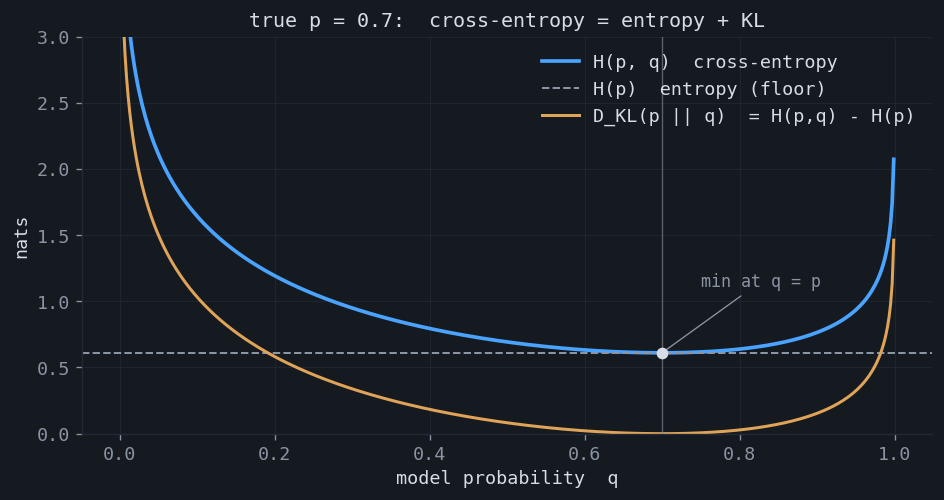

H(p,q)         = 0.7947
H(p) + KL      = 0.7947
identity holds : True


In [3]:
def bern_xent(p, q):   # H(p, q)
    return -(p*np.log(q+eps) + (1-p)*np.log(1-q+eps))

p_true = 0.7
q_grid = np.linspace(1e-3, 1-1e-3, 500)

H_pq = bern_xent(p_true, q_grid)          # cross-entropy
H_p  = bern_xent(p_true, p_true)          # entropy (constant)
KL   = H_pq - H_p                         # divergence

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(q_grid, H_pq, color=ACCENT, lw=2.2, label="H(p, q)  cross-entropy")
ax.axhline(H_p, color=MUTED, ls="--", lw=1.2, label="H(p)  entropy (floor)")
ax.plot(q_grid, KL, color=ACCENT2, lw=1.8, label="D_KL(p || q)  = H(p,q) - H(p)")
ax.axvline(p_true, color=MUTED, lw=0.8, alpha=0.6)
ax.scatter([p_true], [H_p], color=FG, s=36, zorder=5)
ax.annotate("min at q = p", xy=(p_true, H_p), xytext=(p_true+0.05, H_p+0.5),
            color=MUTED, fontsize=10,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_xlabel("model probability  q"); ax.set_ylabel("nats")
ax.set_title(f"true p = {p_true}:  cross-entropy = entropy + KL")
ax.set_ylim(0, 3); ax.legend(); style(ax)
plt.tight_layout(); plt.show()

# numeric check at an arbitrary q
qc = 0.4
print(f"H(p,q)         = {bern_xent(p_true, qc):.4f}")
print(f"H(p) + KL      = {H_p + (bern_xent(p_true, qc) - H_p):.4f}")
print(f"identity holds : {np.isclose(bern_xent(p_true, qc), H_p + (bern_xent(p_true, qc)-H_p))}")

## 3. Calibration: cross-entropy sees what accuracy can't

Take an over-confident 3-class classifier — its logits point the right way often
enough, but they are too sharp. Scale the logits by a temperature $T$ before the
softmax and sweep $T$.

Dividing logits by $T$ never changes which class is largest, so **accuracy is flat**.
But it does reshape the probabilities, so **cross-entropy has a clear minimum** at the
temperature that makes the model honest. This is the proper-scoring-rule view in one
picture — and exactly why temperature scaling is a standard calibration trick.

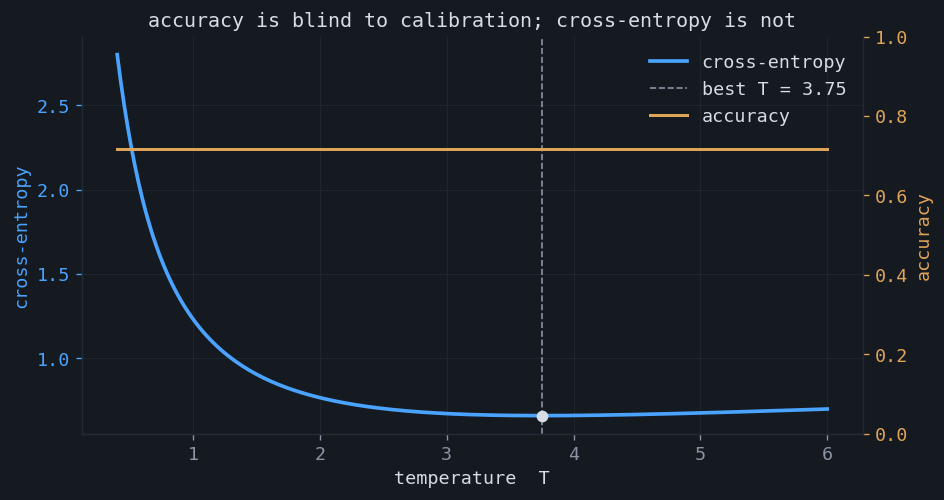

accuracy varies by only 0.0000 across all T
cross-entropy minimized at T = 3.75


In [4]:
C, N = 3, 4000
y = rng.integers(0, C, size=N)                      # true labels

# build logits that are correct ~72% of the time but far too confident
true_logits = np.zeros((N, C))
true_logits[np.arange(N), y] = 2.2
noise = rng.normal(0, 1.6, size=(N, C))
logits = (true_logits + noise) * 3.0                # the *3.0 makes them overconfident

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def metrics_at_T(T):
    probs = softmax(logits / T)
    nll = -np.log(probs[np.arange(N), y] + eps).mean()   # cross-entropy
    acc = (probs.argmax(1) == y).mean()
    return nll, acc

Ts = np.linspace(0.4, 6.0, 200)
nlls = np.array([metrics_at_T(T)[0] for T in Ts])
accs = np.array([metrics_at_T(T)[1] for T in Ts])
T_star = Ts[nlls.argmin()]

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(Ts, nlls, color=ACCENT, lw=2.2, label="cross-entropy")
ax.axvline(T_star, color=MUTED, ls="--", lw=1, label=f"best T = {T_star:.2f}")
ax.scatter([T_star], [nlls.min()], color=FG, s=36, zorder=5)
ax.set_xlabel("temperature  T"); ax.set_ylabel("cross-entropy", color=ACCENT)
ax.tick_params(axis="y", colors=ACCENT)
ax.set_title("accuracy is blind to calibration; cross-entropy is not"); style(ax)

axr = ax.twinx()                                    # accuracy on the right axis
axr.plot(Ts, accs, color=ACCENT2, lw=1.8, label="accuracy")
axr.set_ylabel("accuracy", color=ACCENT2)
axr.tick_params(axis="y", colors=ACCENT2)
axr.set_ylim(0, 1); axr.grid(False)
for s in ("top",): axr.spines[s].set_visible(False)

l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = axr.get_legend_handles_labels()
ax.legend(l1 + l2, lab1 + lab2, loc="upper right")
plt.tight_layout(); plt.show()

print(f"accuracy varies by only {accs.max()-accs.min():.4f} across all T")
print(f"cross-entropy minimized at T = {T_star:.2f}")

## 4. Forward vs. reverse KL on a bimodal target

The target $p$ has two separated bumps. We approximate it with a single Gaussian $q$
and find the best fit under each direction of KL by a small grid search:

- **Forward** $D_{\mathrm{KL}}(p\|q)$ (what cross-entropy minimizes) is mode-**covering** —
  it refuses to leave any mode unexplained, so it stretches wide to cover both.
- **Reverse** $D_{\mathrm{KL}}(q\|p)$ is mode-**seeking** — it would rather sit tightly on
  one bump than place mass in the empty valley between them.

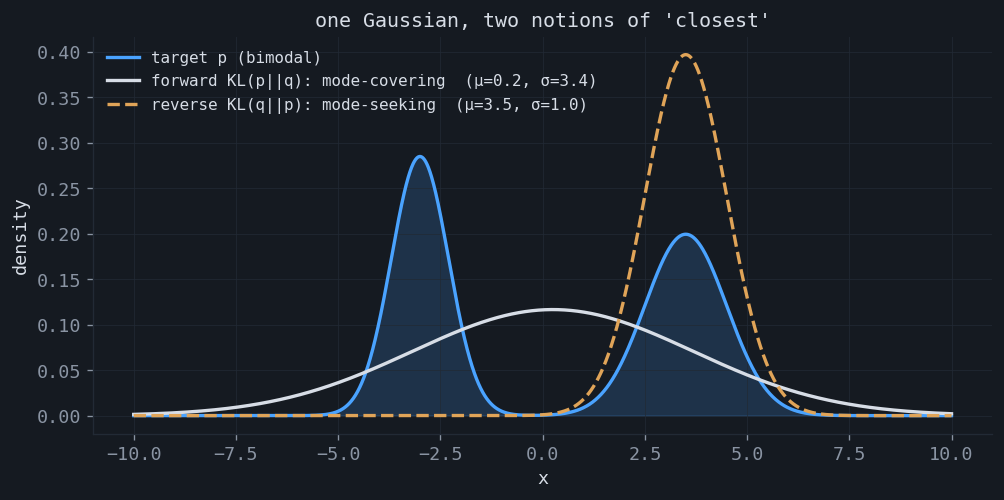

forward  best fit: mu=0.25, sd=3.43  (wide, sits between the modes)
reverse  best fit: mu=3.50, sd=1.01  (narrow, locks onto one mode)


In [5]:
x = np.linspace(-10, 10, 2000)
dx = x[1] - x[0]

def gauss(x, mu, sd):
    return np.exp(-0.5*((x-mu)/sd)**2) / (sd*np.sqrt(2*np.pi))

# bimodal target
p = 0.5*gauss(x, -3.0, 0.7) + 0.5*gauss(x, 3.5, 1.0)
p /= p.sum()*dx

mus = np.linspace(-5, 5, 121)
sds = np.linspace(0.3, 5.0, 121)

best = {"fwd": (np.inf, None), "rev": (np.inf, None)}
for mu in mus:
    for sd in sds:
        q = gauss(x, mu, sd); q /= q.sum()*dx
        fwd = np.sum(p * np.log((p+eps)/(q+eps))) * dx   # KL(p||q)
        rev = np.sum(q * np.log((q+eps)/(p+eps))) * dx   # KL(q||p)
        if fwd < best["fwd"][0]: best["fwd"] = (fwd, (mu, sd))
        if rev < best["rev"][0]: best["rev"] = (rev, (mu, sd))

(mf, sf) = best["fwd"][1]
(mr, sr) = best["rev"][1]
q_fwd = gauss(x, mf, sf); q_fwd /= q_fwd.sum()*dx
q_rev = gauss(x, mr, sr); q_rev /= q_rev.sum()*dx

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.fill_between(x, p, color=ACCENT, alpha=0.18)
ax.plot(x, p, color=ACCENT, lw=2.0, label="target p (bimodal)")
ax.plot(x, q_fwd, color=FG, lw=2.0, ls="-",
        label=f"forward KL(p||q): mode-covering  (μ={mf:.1f}, σ={sf:.1f})")
ax.plot(x, q_rev, color=ACCENT2, lw=2.0, ls="--",
        label=f"reverse KL(q||p): mode-seeking  (μ={mr:.1f}, σ={sr:.1f})")
ax.set_xlabel("x"); ax.set_ylabel("density")
ax.set_title("one Gaussian, two notions of 'closest'")
ax.legend(fontsize=9.5); style(ax)
plt.tight_layout(); plt.show()

print(f"forward  best fit: mu={mf:.2f}, sd={sf:.2f}  (wide, sits between the modes)")
print(f"reverse  best fit: mu={mr:.2f}, sd={sr:.2f}  (narrow, locks onto one mode)")